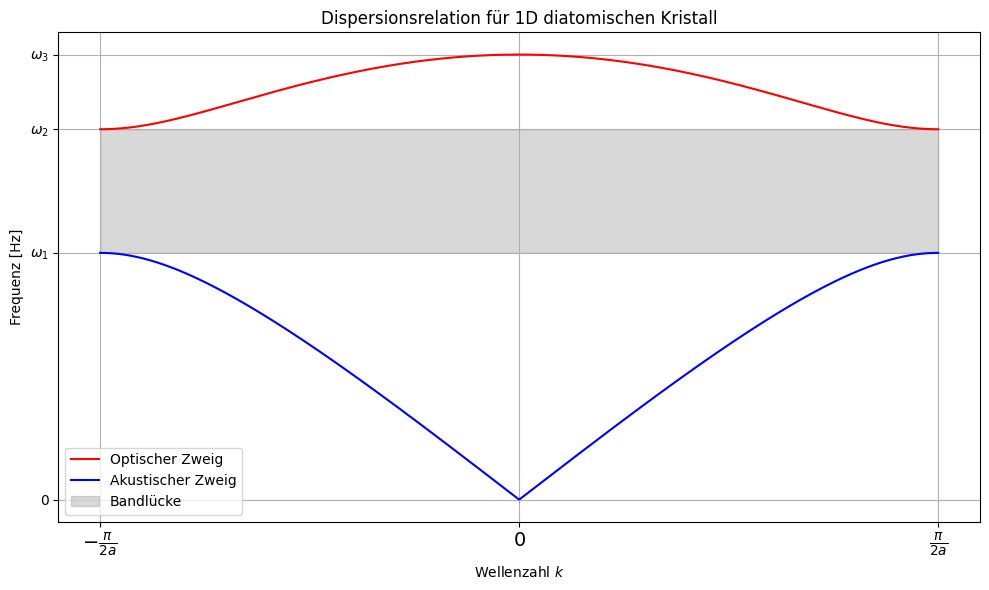

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Gegebene Parameter

beta = 500  # N/m, typische Federkonstante für Silikon
a = 0.013  # Gitterabstand in m
L = 1 # Länge des Gitarrenhalses
f_aim = 250 # Zielfrequenz in Hz
no_yscale = True #boolean

k = np.linspace(-np.pi/(2*a), np.pi/(2*a), 1000) # Wellenzahlen

# Ziel: Deutliche Bandlücke um 220 Hz -> passende m1, m2 wählen

# In kg, z.B. Nanostruktur oder mikro-mechanische Bauelemente

m1 = 0.000633   # aim for 200 Hz
m2 = 0.000281   # aim for 300 Hz

# Dispersionsrelation berechnen

term1 = beta * (1/m1 + 1/m2)
term2 = np.sqrt((beta**2)*(1/m1 + 1/m2)**2 - (4*beta**2)/(m1*m2) * np.sin(k*a)**2)

omega_upper = np.sqrt(term1 + term2)
omega_lower = np.sqrt(term1 - term2)

# Bandlücke berechnen

omega1 = np.sqrt(2 * beta / m1)
omega2 = np.sqrt(2 * beta / m2)

# In Frequenzbereich umrechnen

f_upper = omega_upper / (2*np.pi)
f_lower = omega_lower / (2*np.pi)
f_gap_1 = omega1 / (2*np.pi)
f_gap_2 = omega2 / (2*np.pi)

# Plot

plt.figure(figsize=(10, 6))
plt.plot(k, f_upper, 'r-', label="Optischer Zweig")
plt.plot(k, f_lower, 'b-', label="Akustischer Zweig")
# plt.axhline(f_aim, color='g', linestyle='--', label=f'{f_aim} Hz')
plt.fill_between(k, f_gap_2, f_gap_1, color='gray', alpha=0.3, label='Bandlücke')
plt.title("Dispersionsrelation für 1D diatomischen Kristall")
plt.xlabel("Wellenzahl $k$")
plt.ylabel("Frequenz [Hz]")
plt.legend()
plt.grid(True)

plt.xticks(
ticks=[-np.pi/(2*a), 0, np.pi/(2*a)],
labels=[r"$-\frac{\pi}{2a}$", r"$0$", r"$\frac{\pi}{2a}$"],
fontsize=14
)
if no_yscale:
    plt.yticks([0, f_gap_1, f_gap_2, np.max(f_upper)],
               ["0", r"$\omega_1$", r"$\omega_2$", r"$\omega_3$"]
    )
else:
    print(f"Bandlücke: [{f_gap_2:.2f} Hz, {f_gap_1:.2f} Hz]")
    if f_gap_2 > f_aim > f_gap_1:
        print(f"✅ {f_aim} Hz liegt innerhalb der Bandlücke.")
    else:
        print(f"❌ {f_aim} Hz liegt außerhalb der Bandlücke.")

plt.tight_layout()
plt.show()